In [103]:
from openwind.sar_data import preprocess_sar_data
from openwind.sar_wind import derive_sar_wind
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from nansat import Nansat

In [104]:
%matplotlib inline
%load_ext autoreload
%autoreload 2
import xarray as xr
from openwind.gmf.cmod5n import cmod5n_forward
from tqdm import tqdm

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [105]:
ds = xr.open_dataset('test.nc')

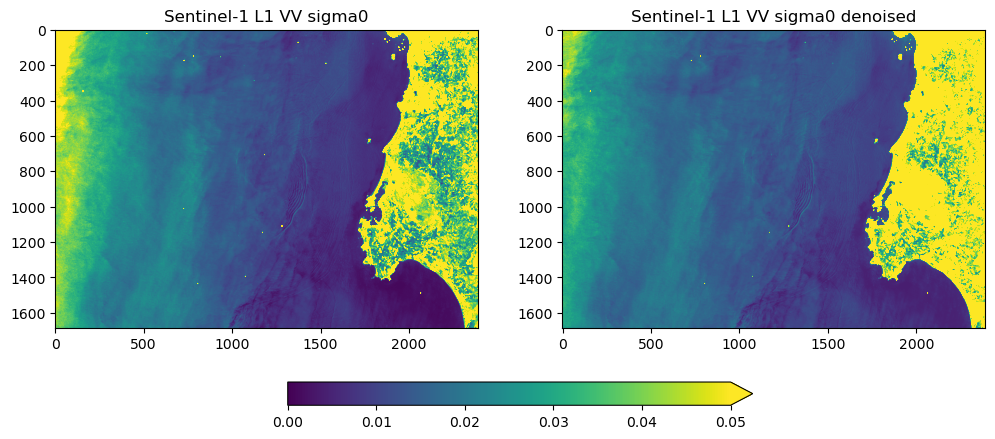

In [113]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 7))
ax1.set_title('Sentinel-1 L1 VV sigma0')
im1 = ax1.imshow(ds.sigma0.data[:, 100:-100], clim=(0, 0.05), cmap='viridis')
ax2.set_title('Sentinel-1 L1 VV sigma0 denoised')
im2 = ax2.imshow(ds.sigma0_s1dn.data[:, 100:-100], clim=(0, 0.05), cmap='viridis')

plt.colorbar(im1, ax=[ax1,ax2], orientation='horizontal', shrink=0.5, pad=0.1, extend='max')
plt.show()

In [114]:
def cmod5n_inverse(sigma0_obs, phi, incidence, iterations: int = 10):
    """
    Inverse wind speed from SAR sigma0 and model wind direction.
    This function iterates the forward CMOD5N function until agreement 
    with input (observed) sigma0 values

    :param sigma0_obs: Normalized Radar Cross Section in linear units
    :param phi:        Angle between azimuth and wind direction (phi = D - AZM) in deg.
    :param incidence:  Incidence angle in deg.
    :param iterations: Number of iterations to run

    :returns V:        Wind speed at 10 m height in m/s, neutral stratification
    """    
    # First guess wind speed
    V = np.full(sigma0_obs.shape, 10)
    step = 3
    
    # Iterating until error is smaller than threshold
    for iterno in tqdm(range(1, iterations), total=len(range(1, iterations))):
        sigma0_calc = cmod5n_forward(V, phi, incidence)
        ind = sigma0_calc - sigma0_obs > 0
        V = V + step
        V[ind] = V[ind] - 2*step 
        step = step/2
    return V

In [115]:
phi = np.mod(ds.wind_dir.data[:, 100:-100] - ds.look_direction.data[:, 100:-100], 360)
sar_wind_spd = cmod5n_inverse(ds.sigma0.data[:, 100:-100], phi, ds.angle_of_incidence.data[:, 100:-100], iterations=10,)


  0%|          | 0/9 [00:00<?, ?it/s]

100%|██████████| 9/9 [00:08<00:00,  1.12it/s]


In [116]:
phi = np.mod(ds.wind_dir.data[:, 100:-100] - ds.look_direction.data[:, 100:-100], 360)
sar_wind_spd_dn = cmod5n_inverse(ds.sigma0_s1dn.data[:, 100:-100], phi, ds.angle_of_incidence.data[:, 100:-100], iterations=10,)


100%|██████████| 9/9 [00:07<00:00,  1.15it/s]


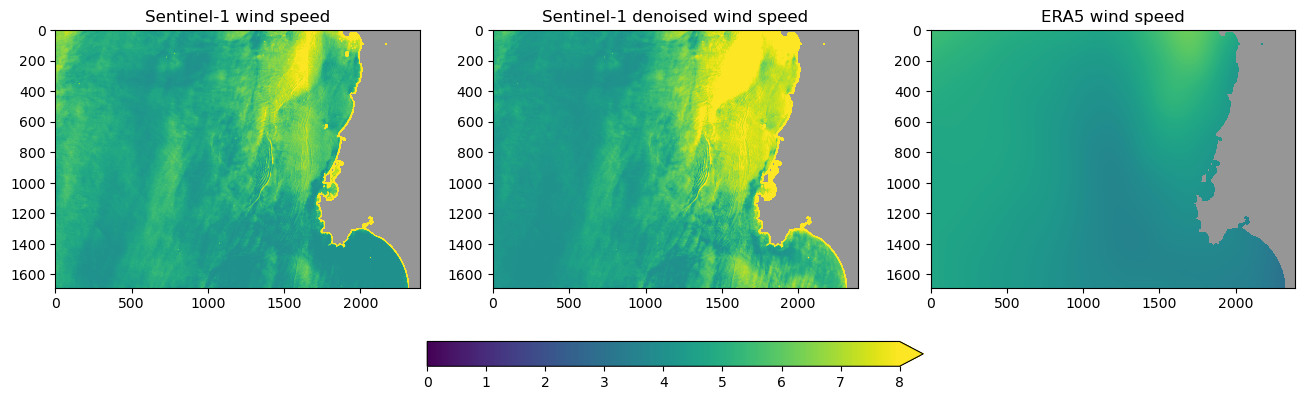

In [128]:
wm = ds.watermask.data[:, 100:-100]
wm[wm == 1] = np.nan


fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 7))
ax1.set_title('Sentinel-1 wind speed')
im1 = ax1.imshow(sar_wind_spd, clim=(0, 8))
ax1.imshow(wm, cmap='Greys_r', clim=(0, 4))
ax2.set_title('Sentinel-1 denoised wind speed')
im2 = ax2.imshow(sar_wind_spd_dn, clim=(0, 8))
ax2.imshow(wm, cmap='Greys_r', clim=(0, 4))

ax3.set_title('ERA5 wind speed')
im3 = ax3.imshow(ds.wind_spd.data[:, 100:-100], clim=(0, 8))
ax3.imshow(wm, cmap='Greys_r', clim=(0, 4))

plt.colorbar(im1, ax=[ax1,ax2,ax3], orientation='horizontal', shrink=0.4, pad=0.1, extend='max')
plt.show()